In [ ]:
!wget https://raw.githubusercontent.com/FIJI-1919/REPOSITORIO_TRABAJO_GRUPAL_EV1/refs/heads/main/data/dataset_clientes.csv

--2026-04-09 03:32:25--  https://raw.githubusercontent.com/FIJI-1919/REPOSITORIO_TRABAJO_GRUPAL_EV1/refs/heads/main/data/dataset_clientes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3282843 (3.1M) [text/plain]
Saving to: ‘dataset_clientes.csv.2’

dataset_clientes.cs 100%[===================>]   3.13M  14.9MB/s    in 0.2s    

2026-04-09 03:32:26 (14.9 MB/s) - ‘dataset_clientes.csv.2’ saved [3282843/3282843]



#Importamos las librerias necesarias para los calculos , porcentajes y graficos

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

#Cargar csv


In [ ]:
data = pd.read_csv('dataset_clientes.csv')

In [ ]:
data.shape

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu

In [ ]:
data.describe()

,id_cliente,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,codigo_postal,abandono
count,20400.000000,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,10004.989853,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,0.501373,11.416716,5488.970147,0.396814
std,5767.007342,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,0.500010,6.891420,2602.374998,0.489249
min,1.000000,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1000.000000,0.000000
25%,5016.750000,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,0.000000,6.000000,3239.000000,0.000000
50%,10014.500000,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,1.000000,11.000000,5477.500000,0.000000
75%,14984.250000,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,1.000000,17.000000,7775.000000,1.000000
max,20000.000000,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,1.000000,23.000000,9998.000000,1.000000


In [ ]:
data.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


#Verificando los datos iniciales

In [ ]:
# Verificamos en todo el dataset los duplicados exactos.
dups_totales = data.duplicated().sum()
print(f"Filas exactamente iguales: {dups_totales}")

# Como podemos podemos ver en el caso de estudio nuestra prioridad fue revisar id cliente, ya que nos mencionaba que existia la posibilidad de duplicados.
dups_id = data['id_cliente'].duplicated().sum()
print(f"ID's de cliente repetidos: {dups_id}")

Filas exactamente iguales: 400
ID's de cliente repetidos: 400


#REVISION DE ATIPICOS FINANCIEROS

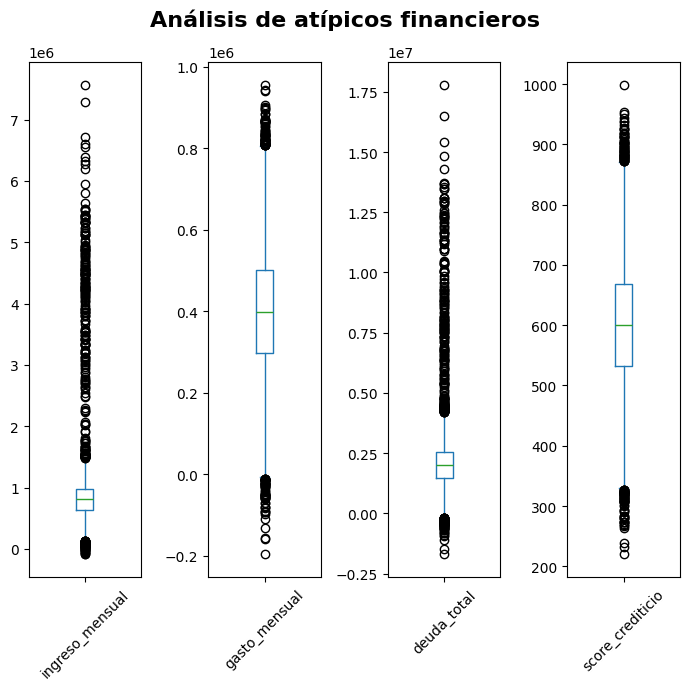

In [ ]:
revision_atipicos_fin = ['ingreso_mensual', 'gasto_mensual', 'deuda_total',	'score_crediticio']
fig, axes = plt.subplots(1, 4, figsize=(18,6))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos_fin):
  data[col].plot(kind='box',figsize=(7,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos financieros", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()
fig.savefig('revision_atipicos_fin.png')
#grafico.savefig
#por la distribución de datos atipicos es lejana optamos por usar la mediana para que no haya sesgo
#Y AQUI NOS DAMOS CUENTA TAMBIEN QUE EXISTEN VALORES NEGATIVOS QUE PARA ESAS VARIABLES POR NATURALEZA NO SON CORRECTOS

#Creación de ratio entre deuda_total e ingreso_mensual
#Para entender que persona esta más asfixiado por las deudas

In [ ]:
#sirve para medir la carga financiera relativa del cliente
data['ratio_deuda'] = data['deuda_total'] / (data['ingreso_mensual'] + 1)

#Tratamos los datos negativos que por naturaleza no deberían ser negativos

In [ ]:
def tratar_negativos(X):
    X = X.copy()

    columnas = ['ingreso_mensual', 'gasto_mensual', 'deuda_total']

    for col in columnas:
        X.loc[X[col] < 0, col] = np.nan

    return X

data = tratar_negativos(data)
#AQUI YA ESTAN TRANSFORMADOS EN NULOS

nulos_por_columna = data.isnull().sum()
print("Resumen de datos faltantes por columna: (los nuevos nulos)")
print(nulos_por_columna[nulos_por_columna > 0])

Resumen de datos faltantes por columna: (los nuevos nulos)
ingreso_mensual     1032
gasto_mensual       1093
deuda_total          143
score_crediticio    1021
ratio_deuda         1021
dtype: int64


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19368 non-null  float64
 7   gasto_mensual          19307 non-null  float64
 8   deuda_total            20257 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu

# Graficamos las Variables Cuantitativas antes de Su limpieza PARA VER DISTRIBUCIÓN ANTES Y DESPSUÉS

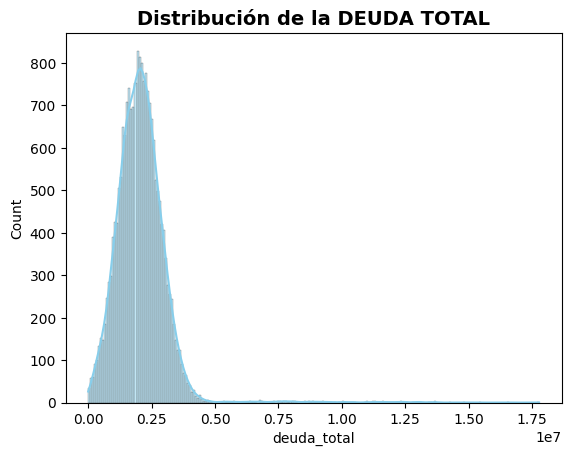

In [ ]:
sns.histplot(data['deuda_total'], kde=True, color="skyblue")
plt.title('Distribución de la DEUDA TOTAL', fontsize=14, fontweight="bold")
plt.show()

fig.savefig('Distribución de la DEUDA TOTAL')

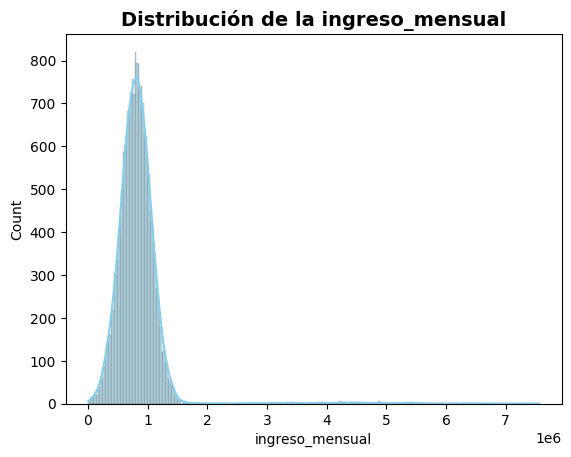

In [ ]:
sns.histplot(data['ingreso_mensual'], kde=True, color="skyblue")
plt.title('Distribución de la ingreso_mensual', fontsize=14, fontweight="bold")
plt.show()

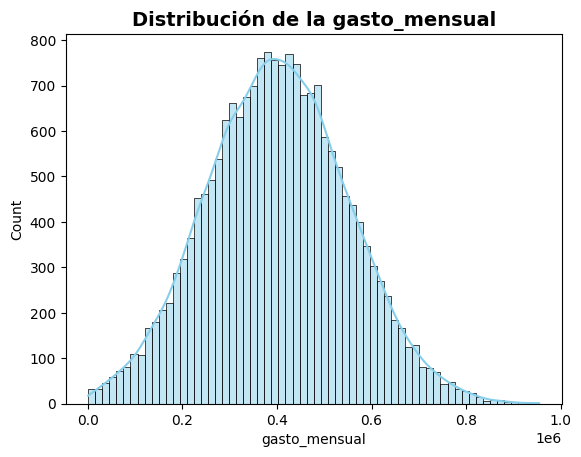

In [ ]:
sns.histplot(data['gasto_mensual'], kde=True, color="skyblue")
plt.title('Distribución de la gasto_mensual', fontsize=14, fontweight="bold")
plt.show()

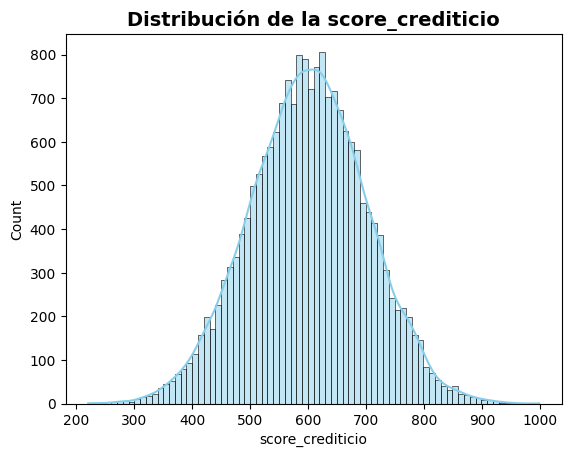

In [ ]:
sns.histplot(data['score_crediticio'], kde=True, color="skyblue")
plt.title('Distribución de la score_crediticio', fontsize=14, fontweight="bold")
plt.show()

#Hacemos limpieza

In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):

  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

#aquí eliminamos duplicados
data = data.drop_duplicates(subset=['id_cliente']).copy()

DEFINIMOS VARIABLES CUANTITATIVAS Y CUALITATIVAS

no contamos con id_cliente ni nombre_cliente porque no aportan al analisis
tampoco con fecha_registro ni fecha_ultima_compra ya que existen otras variables para sacar el tiempo de estas

La imputación se hizo por la mediana ya que cómo habian datos extremos no generar sesgo

In [ ]:
numeric_features = ['edad', 'ingreso_mensual','antiguedad_meses','frecuencia_compra','ultima_compra_dias','num_productos','hora_registro', 'gasto_mensual', 'deuda_total', 'score_crediticio', 'ratio_deuda']
categorical_features = ['genero','estado_civil','canal_registro','dia_semana_registro','tiene_tarjeta_credito','region', 'tipo_plan', 'uso_app']

pipeline_numerico = Pipeline(
    steps=[
        ("winsorizer", Winsorizer()),
        ("imputacion", SimpleImputer(strategy="median"))
    ]
)

pipeline_categorico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("codificacion", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, numeric_features),
        ("cat", pipeline_categorico, categorical_features)
    ]
)

pipeline_limpieza = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador)
    ]
)
data_clean = pipeline_limpieza.fit_transform(data)

data_clean = pd.DataFrame(
    pipeline_limpieza.fit_transform(data),
    columns=pipeline_limpieza.named_steps["preprocesamiento"].get_feature_names_out()
)

# Setea el nombre de las columnas
data_clean.columns = data_clean.columns.str.replace("num__", "")
data_clean.columns = data_clean.columns.str.replace("cat__", "")
data_clean[numeric_features] = data_clean[numeric_features].apply(pd.to_numeric)

data_clean.shape

(20000, 19)

Aquí podemos visualizar nuestros datos limpios, sin duplicados y sin nulos

In [ ]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   edad                   20000 non-null  float64
 1   ingreso_mensual        20000 non-null  float64
 2   antiguedad_meses       20000 non-null  float64
 3   frecuencia_compra      20000 non-null  float64
 4   ultima_compra_dias     20000 non-null  float64
 5   num_productos          20000 non-null  float64
 6   hora_registro          20000 non-null  float64
 7   gasto_mensual          20000 non-null  float64
 8   deuda_total            20000 non-null  float64
 9   score_crediticio       20000 non-null  float64
 10  ratio_deuda            20000 non-null  float64
 11  genero                 20000 non-null  float64
 12  estado_civil           20000 non-null  float64
 13  canal_registro         20000 non-null  float64
 14  dia_semana_registro    20000 non-null  float64
 15  ti

y datos limpios con blockbox(no me acuerdo cómo se escribe)

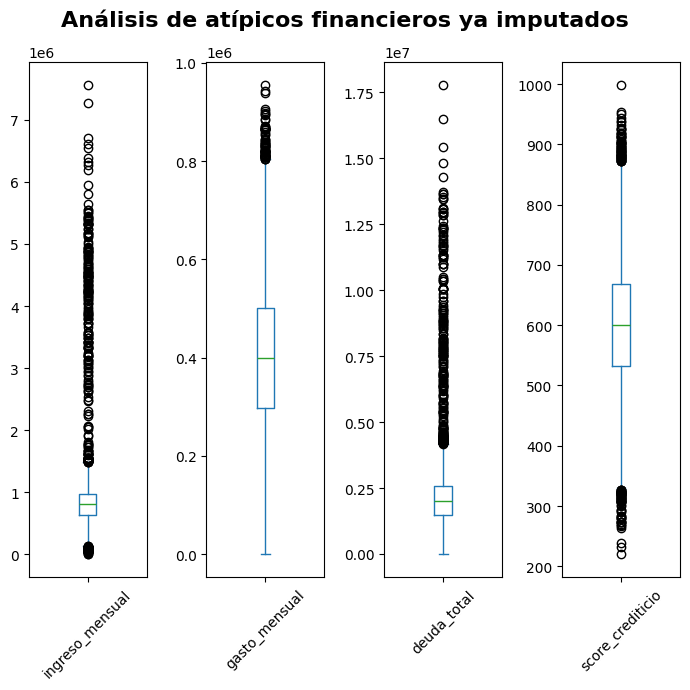

In [ ]:
revision_atipicos_fin = ['ingreso_mensual', 'gasto_mensual', 'deuda_total',	'score_crediticio']
fig, axes = plt.subplots(1, 4, figsize=(18,6))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos_fin):
  data[col].plot(kind='box',figsize=(7,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos financieros ya imputados", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

#Graficos de data limpio para ver cómo funcionan las reglas del negocio


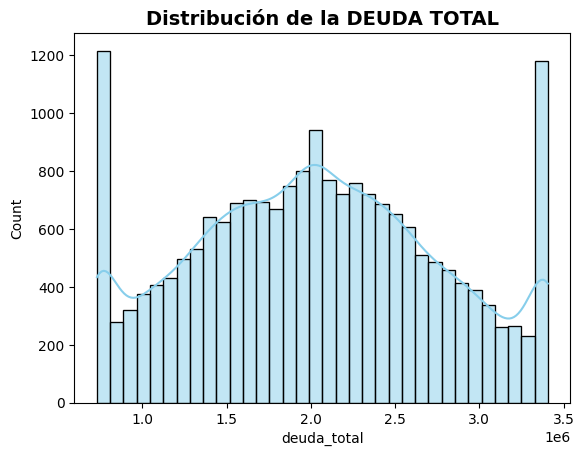

In [ ]:
sns.histplot(data_clean['deuda_total'], kde=True, color="skyblue")
plt.title('Distribución de la DEUDA TOTAL', fontsize=14, fontweight="bold")
plt.show()

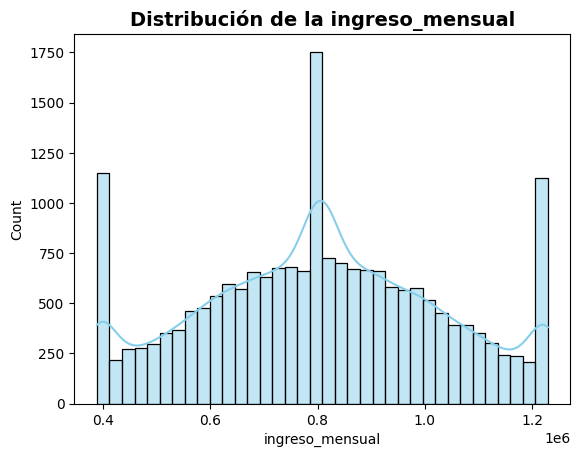

In [ ]:
sns.histplot(data_clean['ingreso_mensual'], kde=True, color="skyblue")
plt.title('Distribución de la ingreso_mensual', fontsize=14, fontweight="bold")
plt.show()

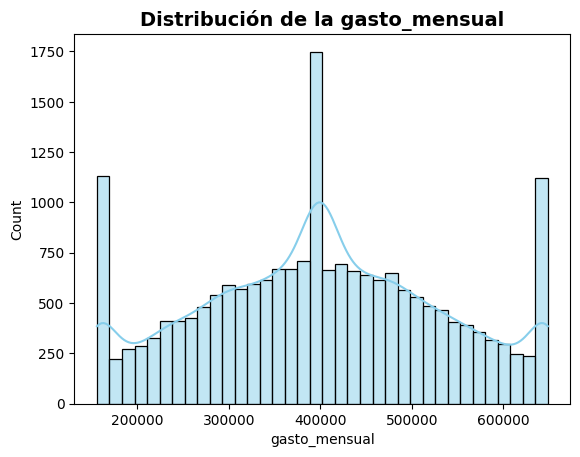

In [ ]:
sns.histplot(data_clean['gasto_mensual'], kde=True, color="skyblue")
plt.title('Distribución de la gasto_mensual', fontsize=14, fontweight="bold")
plt.show()

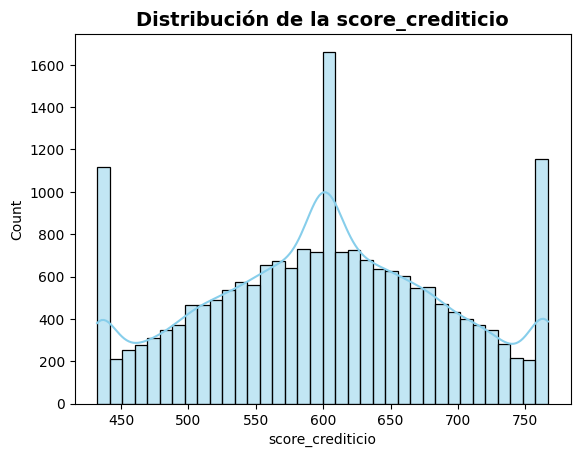

In [ ]:
sns.histplot(data_clean['score_crediticio'], kde=True, color="skyblue")
plt.title('Distribución de la score_crediticio', fontsize=14, fontweight="bold")
plt.show()

TRANSFORMACION

La correlación entre abandono y ultima compra de días

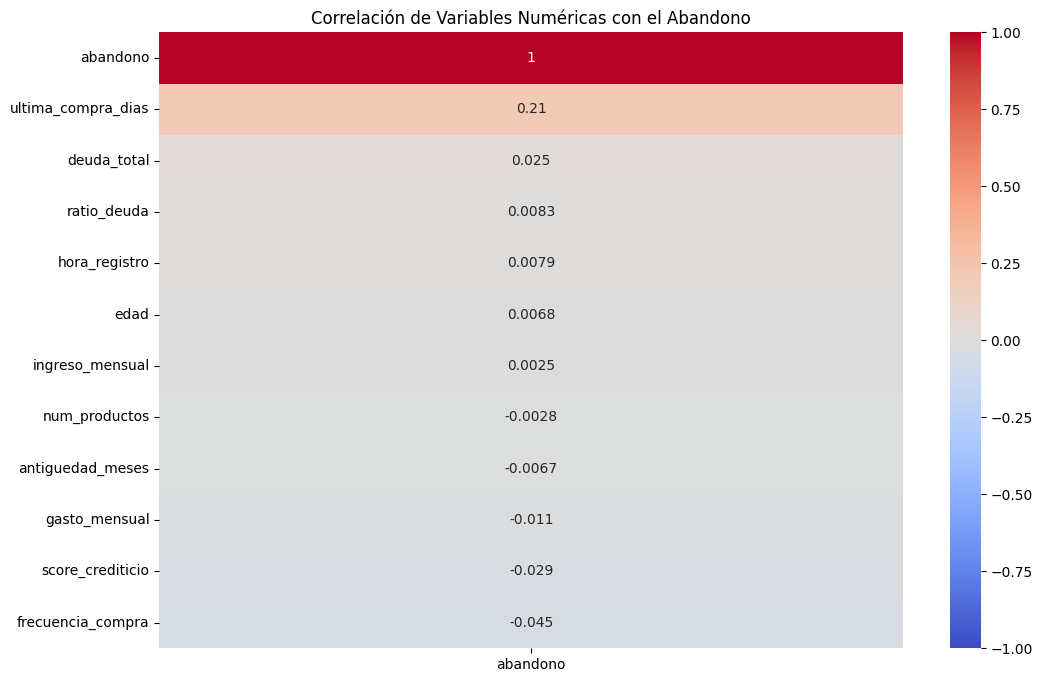

In [ ]:
#Mapa de Calor (Correlación Numérica)
# Muestra cómo se relacionan los números con el abandono
plt.figure(figsize=(12, 8))

# Calculamos la correlación solo de las variables numéricas más nuestra variable abandono
columnas_corr = numeric_features + ['abandono']
correlacion = data[columnas_corr].corr()

# Dibujamos el heatmap
sns.heatmap(correlacion[['abandono']].sort_values(by='abandono', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de Variables Numéricas con el Abandono')
plt.show()

#Este heatmap demuestra que última compra (en días) tiene una alta correlación con la variable abandono
#En otras palabras significa que mientras más días pasan de la ultima compra el cliente más frecuencia de abandono tiene (más días/más abandonos)

#Gráfico para averiguar por tipo de plan o región
#cuál tiene más tasa abandonos

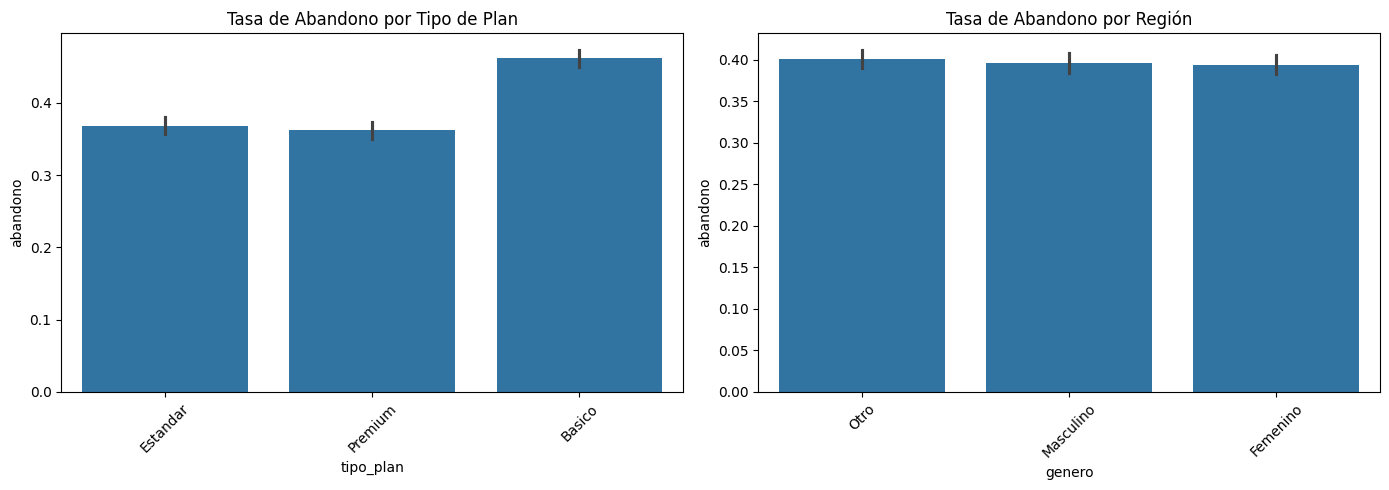

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='tipo_plan', y='abandono', data=data)
plt.title('Tasa de Abandono por Tipo de Plan')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x='genero', y='abandono', data=data)
plt.title('Tasa de Abandono por Región')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
reporte_planes = pd.crosstab(data['tipo_plan'], data['abandono'])
print("\nResumen por tipo de plan y abandono:")
print(reporte_planes)


Resumen por tipo de plan y abandono:
abandono      0     1
tipo_plan            
Basico     3511  3012
Estandar   4253  2480
Premium    4301  2443


A través de este proceso de limpieza, Feature Engineering (creación del ratio_deuda) y análisis exploratorio. Hemos demostrado con evidencia estadística que el abandono de clientes está fuertemente impulsado por factores como la falta de interacción reciente (ultima_compra_dias) y el nivel de estrés financiero.

 Para capitalizar estos descubrimientos y pasar de un análisis descriptivo a una solución proactiva, el siguiente paso lógico es la implementación de un Modelo Predictivo de Machine Learning.

El valor de implementar este modelo predictivo radica en:

Aprendizaje Histórico: El algoritmo utilizará esta base de datos limpia para detectar patrones ocultos y reglas complejas que preceden a la fuga de un usuario.

Scoring de Probabilidad: En lugar de adivinar, el modelo evaluará a los clientes activos y les asignará un porcentaje exacto de riesgo de abandono (del 0% al 100%).

Sistema de Alertas y Retención Temprana: Al clasificar a los clientes en riesgo Alto, Medio o Bajo, la empresa podrá automatizar campañas de retención (descuentos, llamadas, correos) enfocando su presupuesto de marketing exclusivamente en quienes están a punto de irse, salvando la relación antes de que el abandono ocurra.

En definitiva, el trabajo de preparación de datos realizado en este notebook nos proporciona la base sólida y necesaria para construir una herramienta tecnológica que no solo explica el pasado del negocio, sino que anticipa y mejora su futuro.